# Convolutional networks

## Why CNNs for Images?

**Problem with fully-connected layers for images:**
- Image 224×224×3 = 150,528 input neurons
- If first hidden layer has 1000 neurons → 150M parameters!
- No spatial structure awareness

**CNNs solve this with:**
1. **Local connectivity**: Each neuron connects to a small region
2. **Weight sharing**: Same filter applied everywhere
3. **Translation invariance**: Detects features regardless of position

## Convolutional layers

When classifying images, the simplest way to approach them is to understand each pixel as an input *feature*, with our model's output being the classification of the image based on the set of pixels. This becomes very inefficient when the image is very large, since the number of parameters that need to be learned is very large. Additionally, the relevant information in an image is not just the value of each pixel, but also the relationships between them; nearby pixels usually form more complex features than distant pixels.

Convolutional networks are a way to address this problem, as they allow reducing the number of parameters to learn, while maintaining the relevant information from the image. This is achieved through the use of filters that are applied to the image, so that relevant features are extracted from it.

A convolutional layer in a neural network acts as a window (or filter) that moves across the image scanning sets of nearby pixels and looking for a specific pattern in them. In this way, a first step is made to search for higher abstraction *features*, which are then used by subsequent layers to perform the classification.

Convolutional layers are designed to handle data with a high degree of spatial correlation. They are the foundational architecture for **computer vision** tasks. Although CNNs were historically also applied to **Natural Language Processing (NLP)**, since the introduction of the *Transformer* architecture (2017) they have been almost entirely replaced by attention-based models in that domain.


- [Dot CSV - Convolutional Neural Networks! How do they work?](https://www.youtube.com/watch?v=V8j1oENVz00&ab_channel=DotCSV)
- [Dot CSV - Strange Patterns inside a Neural Network!](https://www.youtube.com/watch?v=ysqpl6w6Wzg&ab_channel=DotCSV)
- [Convolution and image filtering](https://programmerclick.com/article/5690865983/)
- [Cezanne Camacho - Convolutional Neural Networks](https://cezannec.github.io/Convolutional_Neural_Networks/)

## Example of edge detection in an image

We can see simple code that applies an edge detection filter to an image. The edges detected are those where there is an abrupt change in the intensity of the image pixels. It's an example of what can be done in the first layers of a convolutional network to detect image features.

We can intuit that edges are an important feature for image classification.

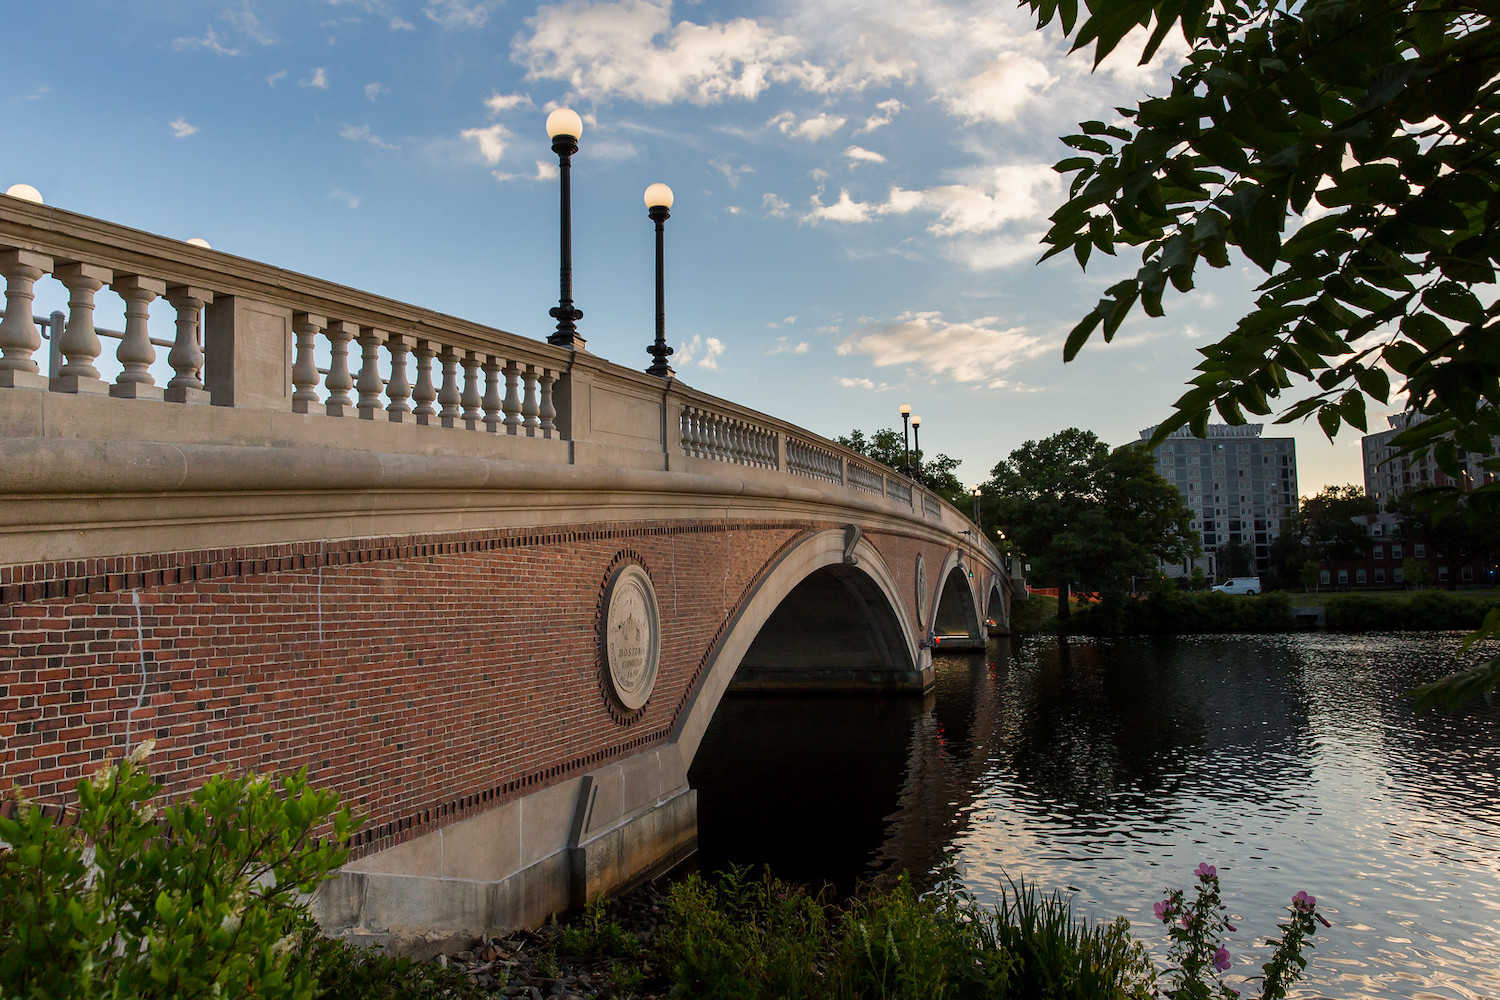

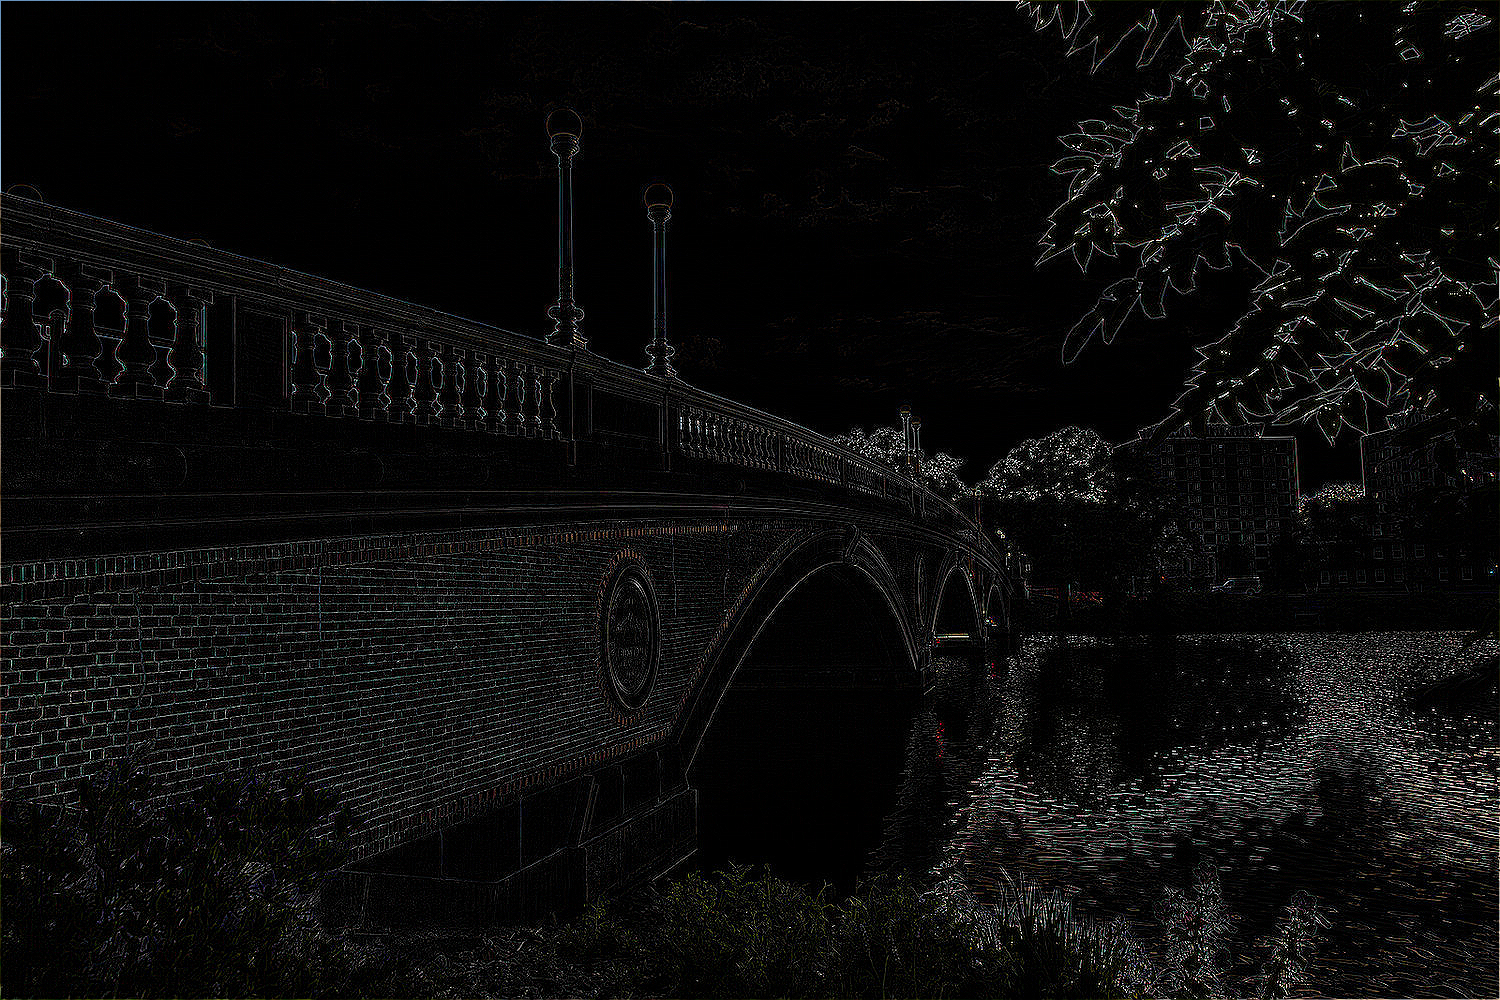

In [ ]:
from PIL import Image, ImageFilter
from IPython.display import display

image_path = "img/bridge.png"
image = Image.open(image_path).convert("RGB")
display(image)

filtered_image = image.filter(ImageFilter.Kernel(
    size=(3, 3), # Kernel size (the window)
    # kernel=[-1, -1, -1, -1, 8, -1, -1, -1, -1], # Window values
     kernel=[0, -1, 0, -1, 4, -1, 0, -1, 0], # Another edge filter
    scale=1 
))
display(filtered_image)

- [How Matrix Filters Work](https://manifold.net/doc/mfd9/how_matrix_filters_work.htm)

In classic Computer Vision, filters like this edge detector were **hand-crafted** by engineers. However, the true power of Convolutional Neural Networks (CNNs) is that they **learn these filters automatically** through backpropagation. Instead of hardcoding an edge detector, we initialize the filters with random values and let the network figure out the mathematically optimal patterns to extract for the given task. Fascinatingly, the filters in the very first layers of a trained CNN almost always naturally evolve into edge and color detectors because the network independently discovers that finding edges is the best first step to understanding an image!

## Convolutional layers in PyTorch

In [ ]:
# PyTorch Conv2d
conv = nn.Conv2d(
    in_channels=1,    # Input channels (1 for grayscale, 3 for RGB)
    out_channels=16,  # Number of filters
    kernel_size=3,    # Filter size
    stride=1,         # Step size
    padding=1         # Keep same spatial size
)

x = torch.randn(1, 1, 28, 28)  # Batch, Channels, Height, Width
output = conv(x)
print(f"Input: {x.shape} → Output: {output.shape}")
print(f"Parameters: {conv.weight.shape} ({conv.weight.numel()} weights + {conv.bias.numel()} biases)")

We can see how a 2-dimensional convolutional layer is defined, with 16 **filters**, each using 3x3 windows/**kernels**, that will shift 1 pixel per step (the **Stride**) and uses a **padding** of 1 pixel to keep the output image of the same size (since the kernel is 3x3, without padding we'll be loosing a row or column in each side).

In this gif you can see how a kernel 3x3 without padding makes the output image loose a line for each border, reducing the image.

![](img/tds_2dconv.gif)

Adding a padding of 1 could solve that:

[![](img/padding.gif)](https://medium.com/@draj0718/zero-padding-in-convolutional-neural-networks-bf1410438e99)

[![](img/edge_handling.gif)](https://cezannec.github.io/Convolutional_Neural_Networks/)

### Stride, padding, and output size

Before implementing convolutions in code, it is useful to predict output dimensions.

For one spatial dimension (height or width):

$$
\text{output} = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1
$$

where:
- \(W\): input size
- \(K\): kernel size
- \(P\): padding
- \(S\): stride

Intuition:
- Larger kernel \(K\) usually decreases output size.
- Larger padding \(P\) increases output size.
- Larger stride \(S\) decreases output size (more aggressive downsampling).

In 2D convolutions, this formula is applied independently to height and width.

In deep-learning frameworks, this operation is mathematically cross-correlation, although it is commonly called convolution.

In [ ]:
# Output size formula: (W - K + 2P) / S + 1
def conv_output_size(input_size, kernel_size, stride=1, padding=0):
    return (input_size - kernel_size + 2 * padding) // stride + 1
examples = [
    {"kernel": 3, "stride": 1, "padding": 0},
    {"kernel": 3, "stride": 1, "padding": 1},
    {"kernel": 3, "stride": 2, "padding": 0},
    {"kernel": 5, "stride": 1, "padding": 0},
]

print("Comparison table for a 28×28 input:")
print("kernel  stride  padding  output")
for case in examples:
    output_size = conv_output_size(28, case["kernel"], case["stride"], case["padding"])
    print(f"{case['kernel']:>6}  {case['stride']:>6}  {case['padding']:>7}  {output_size:>6}")

Output sizes for 28×28 input:
  kernel=3, stride=1, padding=0: 26
  kernel=3, stride=1, padding=1: 28 (same)
  kernel=3, stride=2, padding=0: 13
  kernel=5, stride=1, padding=0: 24


## [CNN Architecture in PyTorch](https://pytorch.org/docs/stable/nn.html#convolution-layers)

The following example shows a classic CNN architecture (LeNet) implemented with PyTorch's `torch.nn` module.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet(nn.Module):

    def __init__(self):
        super().__init__()
        # Assumes input images are 32x32 grayscale (N, 1, 32, 32)
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

The first layer (`torch.nn.Conv2d(1, 6, 5)`) performs a 2D convolution-like operation over the input image.

This layer expects tensors in `N × C × H × W` format. In this example, the expected input is `N × 1 × 32 × 32`:
- The first argument (`1`) is the **number of input channels**. Here, it's 1 for grayscale images. For RGB images it would be 3.
- The second argument (`6`) is the **number of output channels** (filters). The layer learns 6 filters, so it outputs 6 feature maps.
- The third argument (`5`) is the **kernel size**, so each filter uses a 5×5 window.

The output of the first convolution has shape `N × 6 × 28 × 28`.
Then ReLU and max-pooling reduce it to `N × 6 × 14 × 14`.

The next convolutional layer, `conv2 = nn.Conv2d(6, 16, 3)`, expects 6 input channels and produces 16 output channels:
- `N × 6 × 14 × 14` → `N × 16 × 12 × 12` (after `conv2`)
- `N × 16 × 12 × 12` → `N × 16 × 6 × 6` (after max-pooling)

Before passing this output to linear layers, it is reshaped to `N × (16 * 6 * 6) = N × 576`.

### LeNet shape tracking (for input `N × 1 × 32 × 32`)

| Stage | Operation | Output shape |
|---|---|---|
| Input | — | `N × 1 × 32 × 32` |
| `conv1` | `Conv2d(1, 6, 5)` | `N × 6 × 28 × 28` |
| `pool1` | `MaxPool2d(2)` | `N × 6 × 14 × 14` |
| `conv2` | `Conv2d(6, 16, 3)` | `N × 16 × 12 × 12` |
| `pool2` | `MaxPool2d(2)` | `N × 16 × 6 × 6` |
| flatten | reshape | `N × 576` |
| `fc1` | `Linear(576, 120)` | `N × 120` |
| `fc2` | `Linear(120, 84)` | `N × 84` |
| `fc3` | `Linear(84, 10)` | `N × 10` |

If you use `28 × 28` inputs, this architecture needs adaptation (or an input resize step), because the flattened size is no longer `16 × 6 × 6`.

## Feature Maps and Channels

Each convolutional layer produces multiple **feature maps** (output channels), each detecting different features.

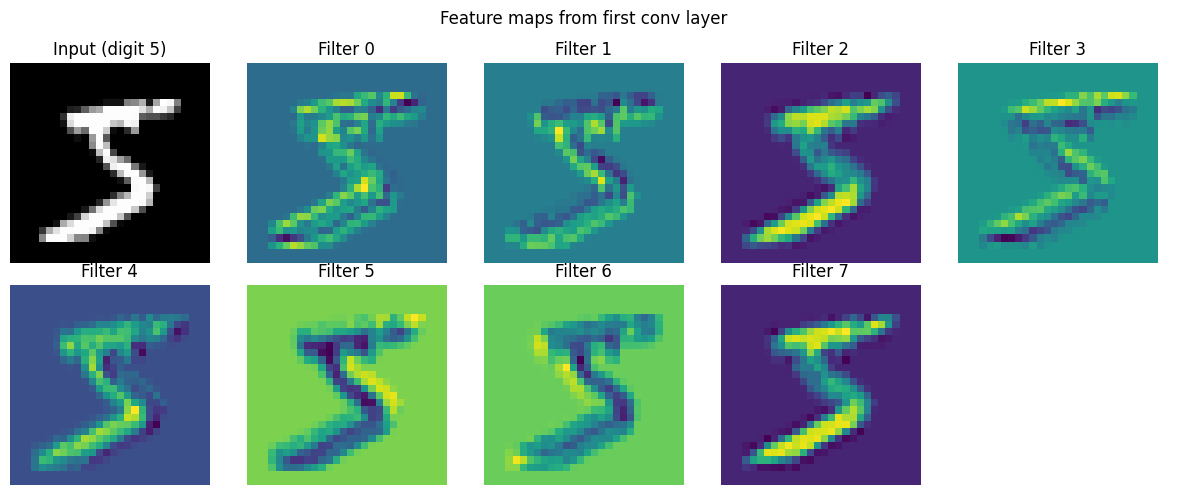

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision import datasets, transforms

transform = transforms.ToTensor()
mnist = datasets.MNIST("./data", train=True, download=True, transform=transform)
sample_image, label = mnist[0]

conv = nn.Conv2d(1, 8, kernel_size=3, padding=1)

with torch.no_grad():
    feature_maps = conv(sample_image.unsqueeze(0))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
all_axes = axes.flat

all_axes[0].imshow(sample_image.squeeze(), cmap="gray")
all_axes[0].set_title(f"Input (digit {label})")
all_axes[0].axis("off")

for filter_index, current_axis in enumerate(all_axes[1:9]):
    current_axis.imshow(feature_maps[0, filter_index].numpy(), cmap="viridis")
    current_axis.set_title(f"Filter {filter_index}")
    current_axis.axis("off")

all_axes[9].axis("off")

plt.suptitle("Feature maps from first conv layer")
plt.tight_layout()
plt.show()

## Pooling Layers

**Pooling** downsamples feature maps, reducing computation and providing translation invariance.

[![](img/MaxpoolSample2.png)](https://computersciencewiki.org/index.php?title=Max-pooling_/_Pooling)

### Why is Max Pooling Useful?

While convolutional layers extract features, max pooling layers are essential for several reasons:
1. **Reduces Computation:** By downsampling the spatial dimension (e.g., halving the width and height), it significantly reduces the number of parameters and subsequent computations.
2. **Translation Invariance:** It makes the network less sensitive to small shifts or translations in the input image. If a feature moves slightly, the max pooling operation will likely still output the same active value.
3. **Extracts Important Features:** By taking the maximum value in a patch, it selects the strongest activation, effectively discarding noisy or less relevant background data.
4. **Prevents Overfitting:** Reducing the spatial resolution forces the network to learn more robust, higher-level features instead of overly relying on exact pixel locations.
5. **Increases Receptive Field:** Because the output map is smaller, subsequent convolutional layers effectively 'see' a much larger area of the original input image.

In [ ]:
# Max pooling vs Average pooling
x = torch.tensor([[[[1., 2., 3., 4.],
                    [5., 6., 7., 8.],
                    [9., 10., 11., 12.],
                    [13., 14., 15., 16.]]]])

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

print(f"Input:\n{x.squeeze()}\n")
print(f"Max pooling (2×2):\n{max_pool(x).squeeze()}\n")
print(f"Avg pooling (2×2):\n{avg_pool(x).squeeze()}")

Input:
tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.],
        [13., 14., 15., 16.]])

Max pooling (2×2):
tensor([[ 6.,  8.],
        [14., 16.]])

Avg pooling (2×2):
tensor([[ 3.5000,  5.5000],
        [11.5000, 13.5000]])


## Sources

- https://cs50.harvard.edu/ai/2024/weeks/5/
- https://pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html
- https://medium.com/thedeephub/convolutional-neural-networks-a-comprehensive-guide-5cc0b5eae175
- https://www.pinecone.io/learn/series/image-search/cnn/
- https://stackoverflow.com/questions/65554032/understanding-convolutional-layers-shapes
- https://dudeperf3ct.github.io/cnn/mnist/2018/10/17/Force-of-Convolutional-Neural-Networks/
- https://poloclub.github.io/cnn-explainer/